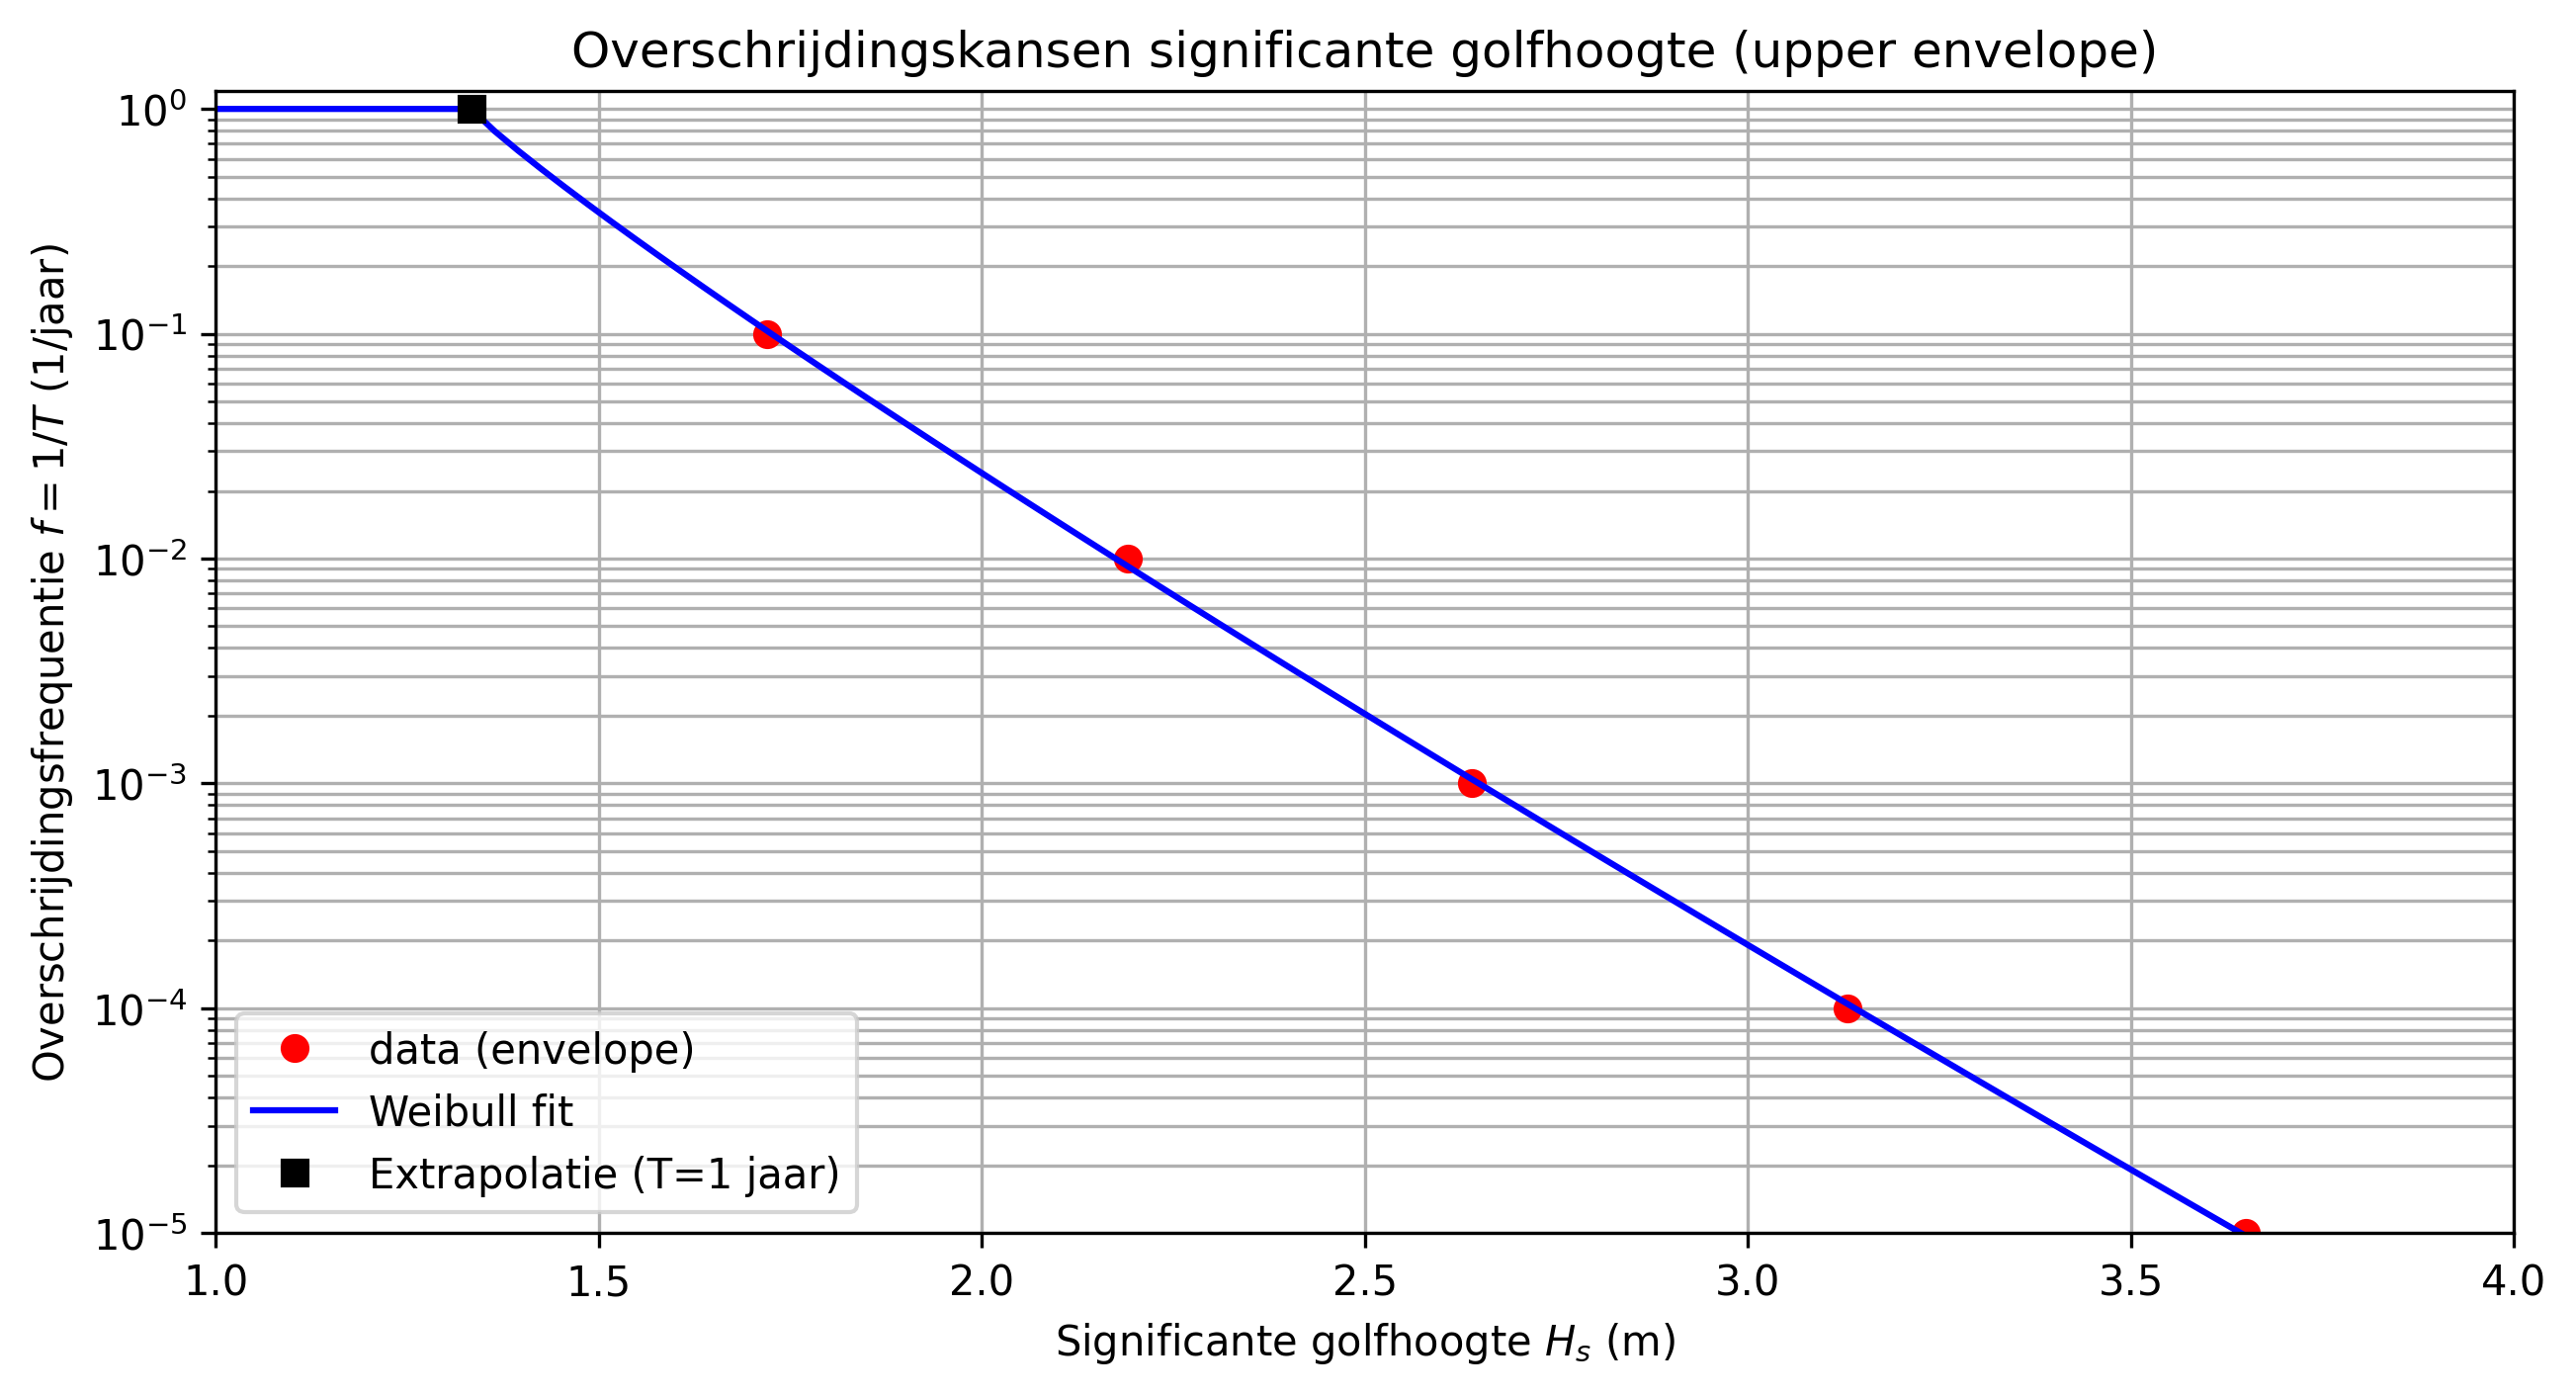

Weibull-fit Hs (op 1/1, 1/10, 1/100 jaar):  a = 0.8023,  b = 1.7312
Aantal sluitingen per jaar (n_events)     :  3.30


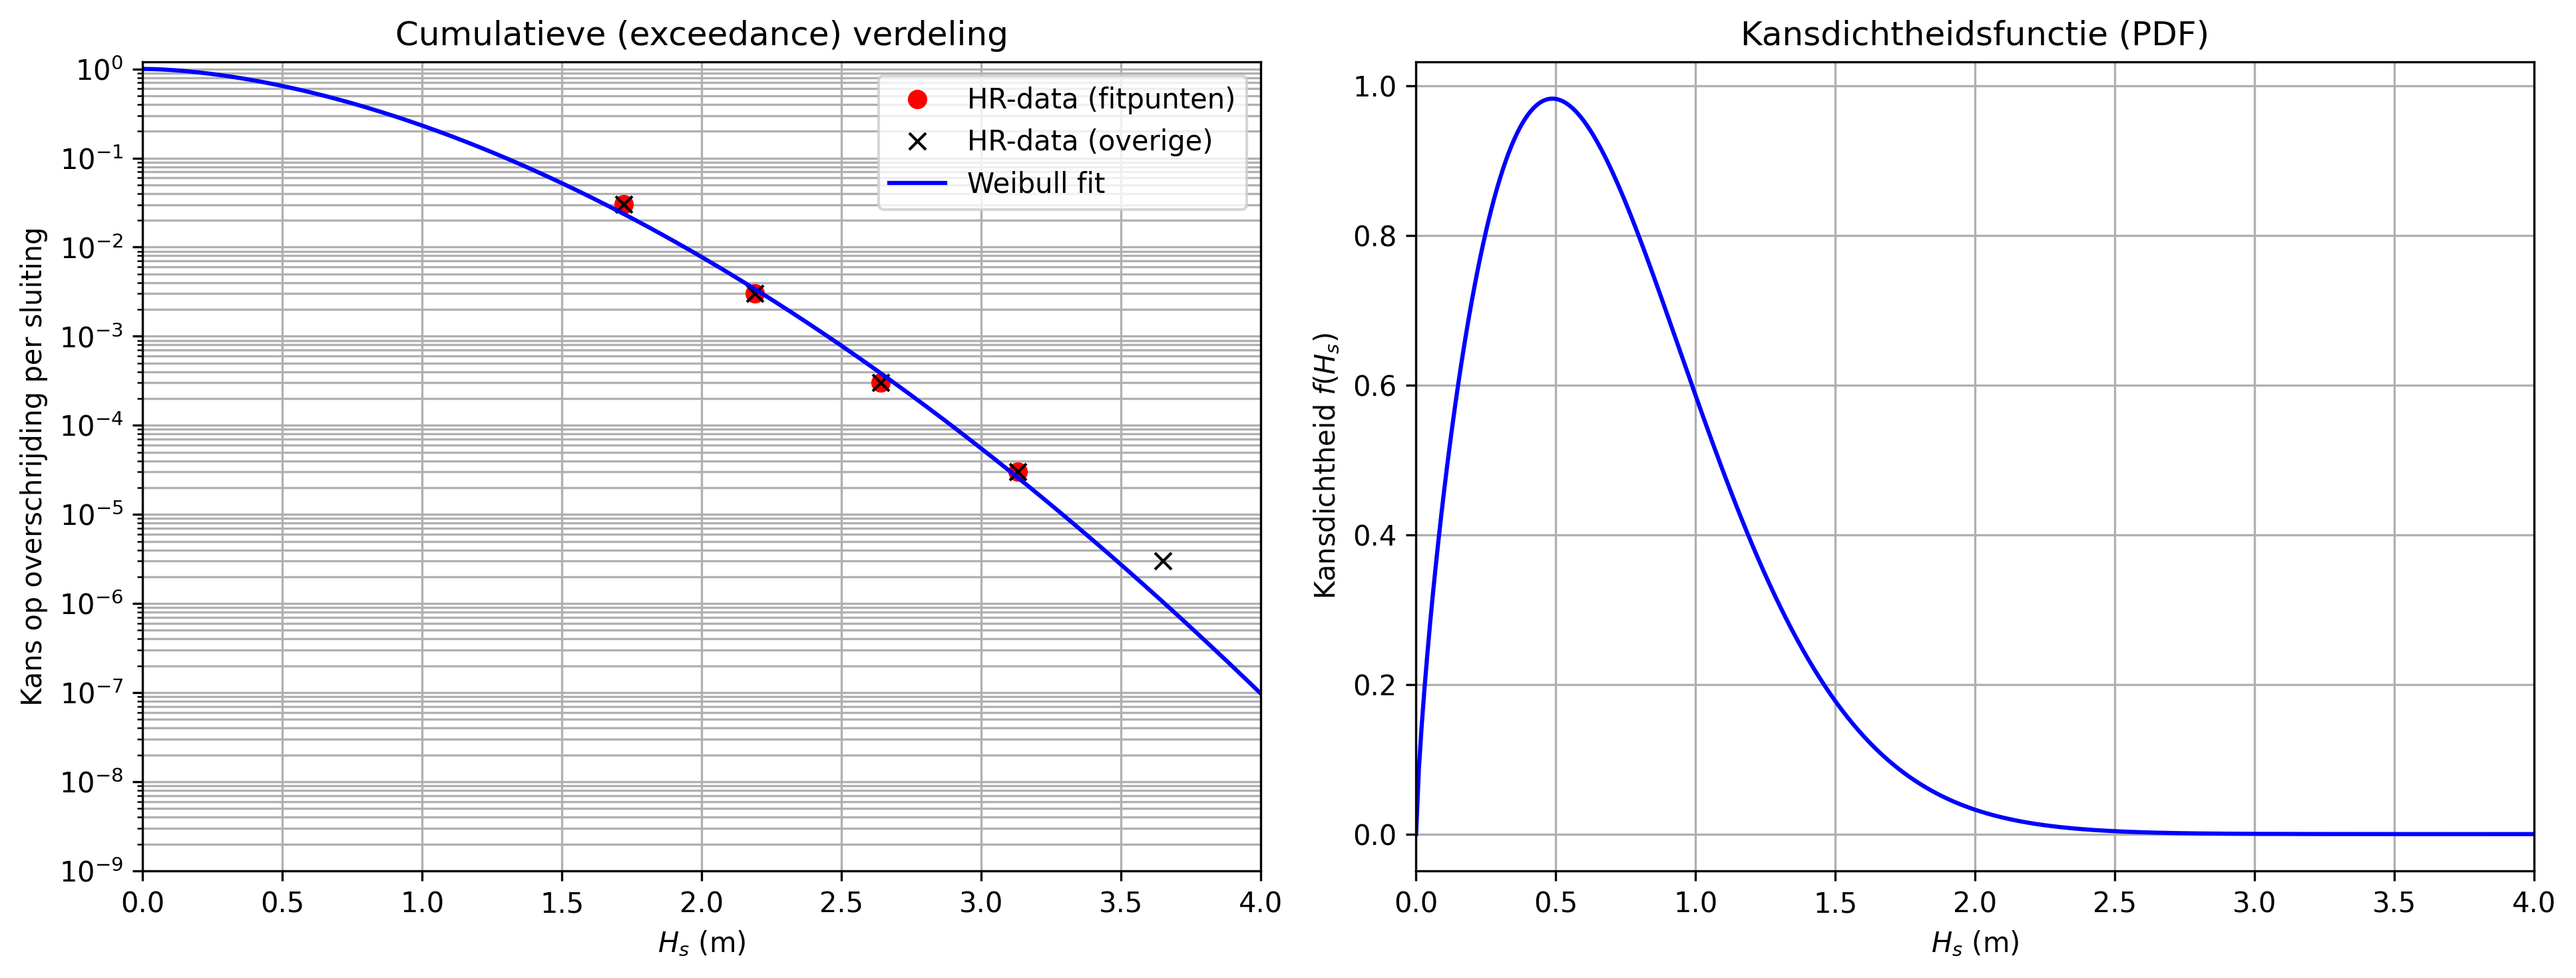

Lineair verband:  Tp = 1.9192 * Hs + 5.5894   (R^2 = 0.9119)


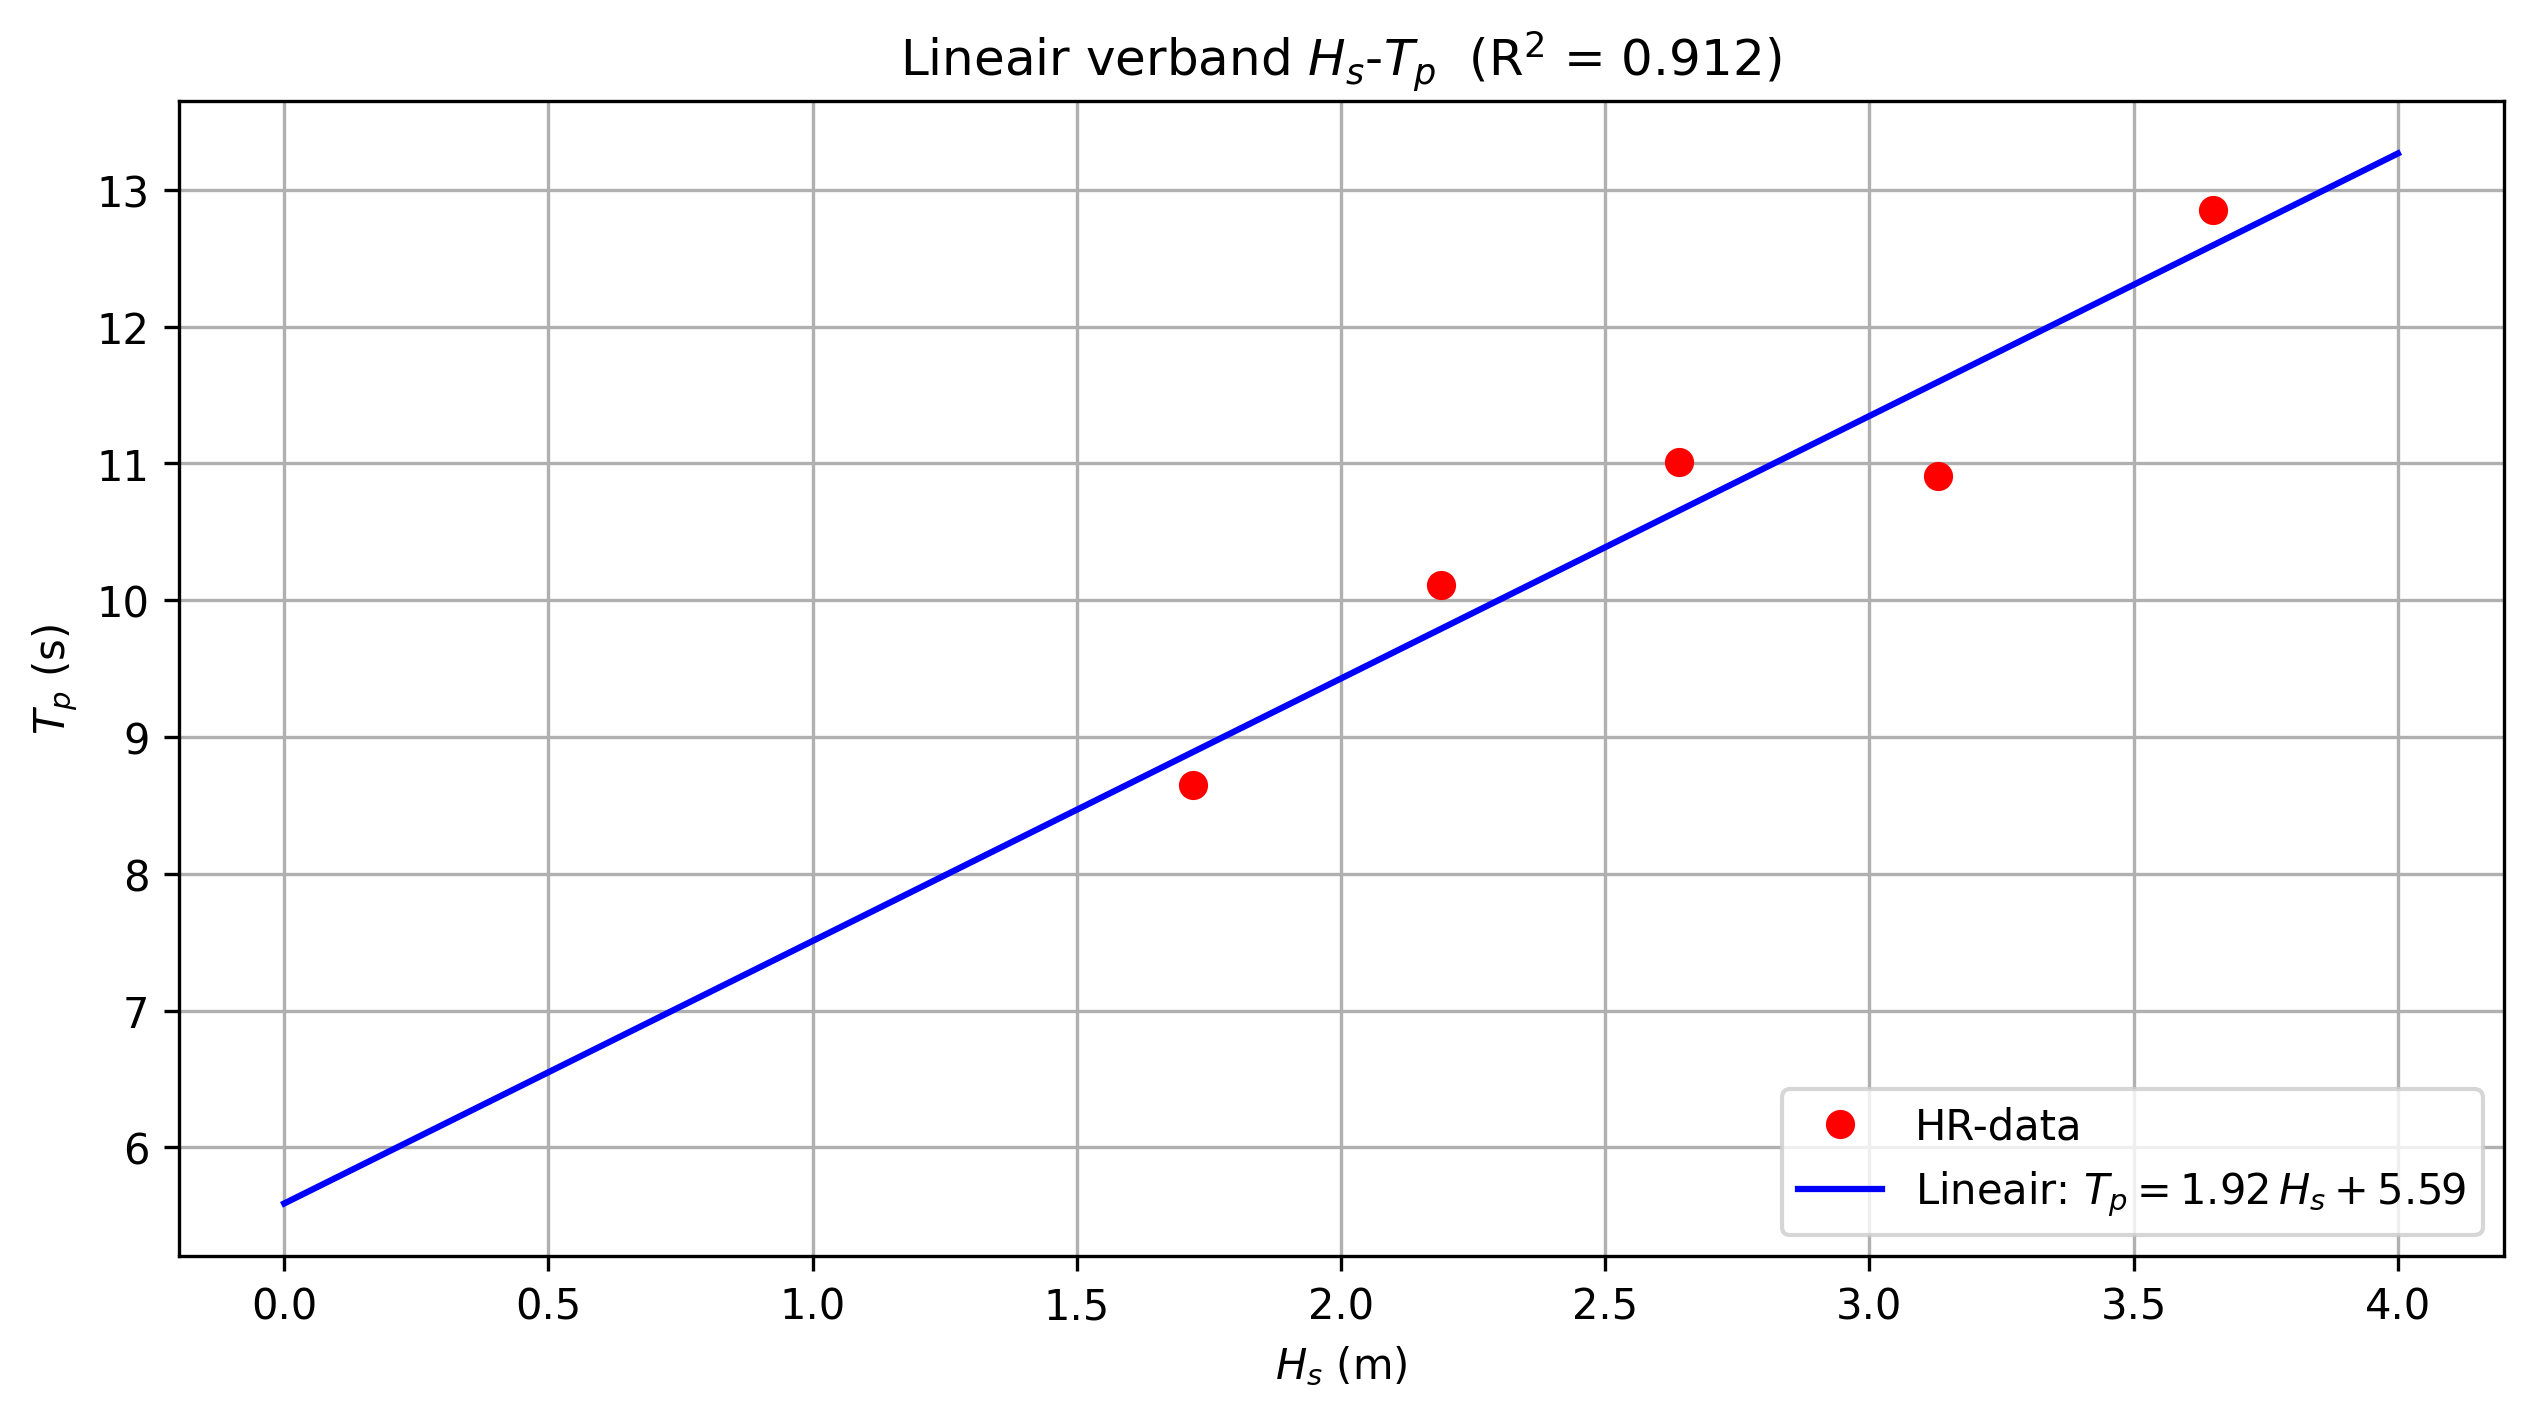


Totaal aantal golfcycli over de levensduur: 5.368e+06

Miner-schade per golfhoogteblok (bin = 0.10 m):
 H_mid (m)   n_i (-)  dSigma_i (MPa)    N_R,i (-)  D_i (-)
      0.05  465732.0            3.29          inf   0.0000
      0.15  765533.0            9.86          inf   0.0000
      0.25 1089789.0           16.43          inf   0.0000
      0.35  600242.0           23.01          inf   0.0000
      0.45  495959.0           29.58 8.652621e+07   0.0057
      0.55  573442.0           36.15 3.172465e+07   0.0181
      0.65  289214.0           42.72 1.376079e+07   0.0210
      0.75  230175.0           49.30 6.728278e+06   0.0342
      0.85  182457.0           55.87 4.104473e+06   0.0445
      0.95  204480.0           62.44 2.939973e+06   0.0696
      1.05  100971.0           69.02 2.177440e+06   0.0464
      1.15  112599.0           75.59 1.657374e+06   0.0679
      1.25   55400.0           82.16 1.290578e+06   0.0429
      1.35   43519.0           88.74 1.024502e+06   0.0425
      1.45 

In [1]:
"""
==========================================================================
METHODE 3 - Vermoeiingsbelasting uit probabilistisch golfklimaat
                     (Nieuwe Waterweg, HR-statistiek)
==========================================================================
Bepaalt het aantal golfwisselingen en de bijbehorende schade (Palmgren-
Miner, FAT 71) op basis van de volledige, continue kansverdeling van de
significante golfhoogte Hs, in plaats van een beperkt aantal discrete
retourklassen (zoals in Methode 1 en 2).

Stappenplan:
  Stap 1  Upper envelope van de HR-data + Weibull-extrapolatie naar T=1 jaar.
  Stap 2  Omzetten van jaarlijkse overschrijdingsfrequentie naar kans per
          sluiting (n_events = 330 sluitingen / 100 jaar = 3.3 /jaar).
  Stap 3  Weibull-fit op de kans per sluiting (1/1, 1/10, 1/100 jaar) ->
          kansdichtheidsfunctie (pdf) van Hs.
  Stap 4  Discretiseren van de pdf in stormklassen (0-4 m).
  Stap 5  Lineair verband Tp(Hs) uit de HR-data.
  Stap 6  Rayleigh-verdeling van individuele golven per stormklasse ->
          aantal golfcycli per fijne golfhoogte-bin, over de levensduur.
  Stap 7  Herbinnen naar blokken van 0.10 m, spanningsrange en toelaatbaar
          aantal wisselingen (FAT 71), Miner-schade per blok en totaal.
==========================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import quad

EPS = 1e-12

# ==========================================================================
# 0) INVOERPARAMETERS
# ==========================================================================
T_storm       = 35.0     # [uur] stormduur (aanname)
N_jaar        = 100.0    # [jaar] ontwerplevensduur
n_sluitingen  = 330      # [-] totaal aantal sluitingen over de levensduur (Sectie closure_frequency)
n_events_jaar = n_sluitingen / N_jaar   # [1/jaar] gemiddeld aantal sluitingen per jaar = 3.3

# --- FAT 71 S-N-curve (NEN-EN 1993-1-9) ---------------------------------
FAT_CLASS = 71.0     # Delta sigma_C [MPa] bij N = 2e6
N_C, N_D, N_L = 2.0e6, 5.0e6, 1.0e8
M1, M2 = 3.0, 5.0

delta_sigma_D = FAT_CLASS * (N_C / N_D) ** (1.0 / M1)      # 52.31 MPa
delta_sigma_L = delta_sigma_D * (N_D / N_L) ** (1.0 / M2)   # 28.73 MPa

# --- Spanningsgradiënt (Sectie stress_range_lwt) ------------------------
sigma_grad = 65.73   # [MPa/m] spanningsrange per meter golfhoogte


def allowable_cycles_fat71(dsigma):
    """Toelaatbaar aantal wisselingen N_R volgens de bilineaire FAT71-curve."""
    dsigma = np.asarray(dsigma, dtype=float)
    N_R = np.full_like(dsigma, np.inf)

    mask_m3 = dsigma >= delta_sigma_D
    N_R[mask_m3] = N_C * (FAT_CLASS / dsigma[mask_m3]) ** M1

    mask_m5 = (dsigma > delta_sigma_L) & (dsigma < delta_sigma_D)
    N_R[mask_m5] = N_D * (delta_sigma_D / dsigma[mask_m5]) ** M2

    return N_R


# ==========================================================================
# 1) INLEZEN HR-DATA
# ==========================================================================
file_path = r"C:\Users\saldenh2867\OneDrive - ARCADIS\Documents\Python\NieuweWaterweg.xlsx"

waterlevel_col     = "Waterstandsniveau [m+NAP]"
Hs_col             = "Golfhoogte [m]"
Tp_col             = "Piekperiode [s]"
return_period_col  = "Terugkeertijd [jaar]"

df = pd.read_excel(file_path)
df["Frequency"] = 1.0 / df[return_period_col]
Freq_col = "Frequency"

df = df[[Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]].dropna()

for col in [Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce"
    )

df = df.dropna().sort_values(return_period_col).set_index(return_period_col)


# ==========================================================================
# 2) STAP 1 - UPPER ENVELOPE + EXTRAPOLATIE NAAR T = 1 JAAR
# ==========================================================================
env = (
    df.reset_index()
    .dropna(subset=[Hs_col, Tp_col, waterlevel_col, Freq_col])
    .sort_values(Hs_col)
    .drop_duplicates(subset=Freq_col, keep="last")
    .rename(columns={
        return_period_col: "T_return",
        Freq_col: "Freq per jaar",
        waterlevel_col: "WL_at_Hs_upper",
        Hs_col: "Hs (m)",
        Tp_col: "Tp_at_Hs_upper",
    })
)

# Monotone (dalende) frequentie t.o.v. stijgende Hs
env["Freq_mono"] = np.minimum.accumulate(env["Freq per jaar"].to_numpy())

H_env = env["Hs (m)"].to_numpy(float)
p_env = np.clip(env["Freq_mono"].to_numpy(float), EPS, 1 - EPS)


def weibull_exceed_3p(H, a, b, c):
    """3-parameter Weibull-overschrijdingskans: P(H) = exp(-((H-c)/a)^b)."""
    x = np.clip((np.asarray(H, float) - c) / a, 0.0, None)
    return np.exp(-(x ** b))


def resid_envelope(par):
    a, b, c = par
    P_mod = np.clip(weibull_exceed_3p(H_env, a, b, c), EPS, 1 - EPS)
    return np.log(p_env) - np.log(P_mod)


x0     = [np.percentile(H_env, 90), 2.0, H_env.min() - 0.05]
bounds = ([1e-6, 0.3, -1.0], [10 * H_env.max(), 30.0, H_env.min()])
a_env, b_env, c_env = least_squares(
    resid_envelope, x0, bounds=bounds, loss="soft_l1", max_nfev=20000
).x

# Extrapolatie naar T = 1 jaar: bij P=1 geldt H = c
Hs_T1 = c_env
WL_T1 = np.poly1d(np.polyfit(H_env, env["WL_at_Hs_upper"], 1))(Hs_T1)
Tp_T1 = np.poly1d(np.polyfit(H_env, env["Tp_at_Hs_upper"], 1))(Hs_T1)

row_T1 = pd.DataFrame([{
    "T_return": 1.0, "Freq per jaar": 1.0,
    "Hs (m)": Hs_T1, "Tp_at_Hs_upper": Tp_T1, "WL_at_Hs_upper": WL_T1,
}])
cols = ["T_return", "Freq per jaar", "Hs (m)", "Tp_at_Hs_upper", "WL_at_Hs_upper"]
df_waves = (
    pd.concat([row_T1, env[cols]], ignore_index=True)
    .sort_values("T_return")
    .reset_index(drop=True)
    .set_index("T_return")
)

# Controleplot: envelope-fit
H_grid = np.linspace(1.0, 4.0, 100)
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(H_env, p_env, "ro", label="data (envelope)")
plt.plot(H_grid, np.clip(weibull_exceed_3p(H_grid, a_env, b_env, c_env), EPS, 1 - EPS),
         "b-", label="Weibull fit")
plt.plot([Hs_T1], [1.0], "ks", label="Extrapolatie (T=1 jaar)")
plt.yscale("log"); plt.ylim(1e-5, 1.2); plt.xlim(1, 4)
plt.grid(True, which="both")
plt.xlabel("Significante golfhoogte $H_s$ (m)")
plt.ylabel("Overschrijdingsfrequentie $f = 1/T$ (1/jaar)")
plt.legend(loc="lower left")
plt.title("Overschrijdingskansen significante golfhoogte (upper envelope)")
plt.show()


# ==========================================================================
# 3) STAP 2 & 3 - KANS PER SLUITING + WEIBULL-FIT OP Hs
# ==========================================================================
env = env.sort_values("Hs (m)").reset_index(drop=True)
env["P_event"] = env["Freq_mono"] / n_events_jaar   # kans per sluiting (n_events = 3.3/jaar)

fit_mask = env["T_return"] <= 10000
H_fit = env.loc[fit_mask, "Hs (m)"].to_numpy(float)
P_fit = env.loc[fit_mask, "P_event"].to_numpy(float)


def weibull_exceed_2p(H, a, b):
    return np.exp(-(np.asarray(H, float) / a) ** b)


def resid_hs(par):
    a, b = par
    P_mod = np.clip(weibull_exceed_2p(H_fit, a, b), 1e-300, 1.0)
    return np.log(P_fit) - np.log(P_mod)


a_hs, b_hs = least_squares(
    resid_hs, x0=[1.0, 2.0], bounds=([1e-6, 0.3], [50.0, 30.0]),
    loss="soft_l1", max_nfev=20000
).x
print(f"Weibull-fit Hs (op 1/1, 1/10, 1/100 jaar):  a = {a_hs:.4f},  b = {b_hs:.4f}")
print(f"Aantal sluitingen per jaar (n_events)     :  {n_events_jaar:.2f}")


def weibull_pdf_hs(H):
    H = np.asarray(H, float)
    return (b_hs / a_hs) * (H / a_hs) ** (b_hs - 1) * np.exp(-(H / a_hs) ** b_hs)


# Controleplot: exceedance + pdf
H_grid = np.linspace(0.0, 4.0, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

ax1.plot(H_fit, P_fit, "ro", label="HR-data (fitpunten)")
ax1.plot(env["Hs (m)"], env["P_event"], "kx", label="HR-data (overige)")
ax1.plot(H_grid, weibull_exceed_2p(H_grid, a_hs, b_hs), "b-", label="Weibull fit")
ax1.set_yscale("log"); ax1.set_ylim(1e-9, 1.2); ax1.set_xlim(0, 4)
ax1.grid(True, which="both")
ax1.set_xlabel(r"$H_s$ (m)"); ax1.set_ylabel(r"Kans op overschrijding per sluiting")
ax1.set_title("Cumulatieve (exceedance) verdeling"); ax1.legend()

ax2.plot(H_grid, weibull_pdf_hs(H_grid), "b-")
ax2.grid(True); ax2.set_xlim(0, 4)
ax2.set_xlabel(r"$H_s$ (m)"); ax2.set_ylabel(r"Kansdichtheid $f(H_s)$")
ax2.set_title("Kansdichtheidsfunctie (PDF)")
plt.tight_layout(); plt.show()


# ==========================================================================
# 4) STAP 4 - DISCRETISATIE IN STORMKLASSEN (0-6 m)
# ==========================================================================
Hs_out   = np.linspace(0, 6, 60)
Prob_bin = np.array([
    quad(weibull_pdf_hs, Hs_out[i], Hs_out[i + 1])[0] for i in range(len(Hs_out) - 1)
])
T_golfveld = Prob_bin * n_events_jaar * T_storm   # duur per jaar [uur] van elke stormklasse

df_out_duur = pd.DataFrame({
    "Hm0 (m)": Hs_out[1:],
    "Prob (-)": Prob_bin,
    "Duur per jaar (uur)": T_golfveld,
})


# ==========================================================================
# 5) STAP 5 - LINEAIR VERBAND Tp(Hs)
# ==========================================================================
Hs_data = env["Hs (m)"].to_numpy(float)
Tp_data = env["Tp_at_Hs_upper"].to_numpy(float)

m_tp, q_tp = np.polyfit(Hs_data, Tp_data, 1)


def Tp_lin(H):
    return m_tp * np.asarray(H, float) + q_tp


pred = Tp_lin(Hs_data)
R2 = 1.0 - np.sum((Tp_data - pred) ** 2) / np.sum((Tp_data - Tp_data.mean()) ** 2)
print(f"Lineair verband:  Tp = {m_tp:.4f} * Hs + {q_tp:.4f}   (R^2 = {R2:.4f})")

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(Hs_data, Tp_data, "ro", label="HR-data")
plt.plot(H_grid, Tp_lin(H_grid), "b-", label=f"Lineair: $T_p = {m_tp:.2f}\\,H_s + {q_tp:.2f}$")
plt.xlabel(r"$H_s$ (m)"); plt.ylabel(r"$T_p$ (s)")
plt.title(f"Lineair verband $H_s$-$T_p$  (R$^2$ = {R2:.3f})")
plt.grid(True); plt.legend(loc="lower right")
plt.show()

df_out_duur["Tm-10"] = Tp_lin(df_out_duur["Hm0 (m)"].to_numpy())
df_out_duur["Tp"]    = df_out_duur["Tm-10"] / 0.9   # Tm-10 -> Tp conversie


# ==========================================================================
# 6) STAP 6 - RAYLEIGH-VERDELING BINNEN ELKE STORMKLASSE
# ==========================================================================
def f_rayleigh(H, Hm0):
    """Rayleigh-kansdichtheid van individuele golfhoogte H binnen golfveld met Hm0."""
    return (4.0 * H / Hm0 ** 2) * np.exp(-2.0 * (H / Hm0) ** 2)


H_out_rayleigh = np.linspace(0, 6, 141)   # fijne golfhoogte-as, stap ~0.043 m


def prob_rayleigh_bins(Hm0):
    """Kans per fijne golfhoogte-bin binnen een golfveld met significante hoogte Hm0."""
    return np.array([
        quad(f_rayleigh, H_out_rayleigh[i], H_out_rayleigh[i + 1], args=(Hm0,))[0]
        for i in range(len(H_out_rayleigh) - 1)
    ])


def n_golf_per_uur(Hm0, Tp):
    """Aantal golven per uur binnen elke fijne golfhoogte-bin."""
    N_tot_uur = 3600.0 / Tp
    return prob_rayleigh_bins(Hm0) * N_tot_uur


# Totaal aantal golfcycli per fijne golfhoogte-bin, over de levensduur
n_classes = len(df_out_duur)
n_bins    = len(H_out_rayleigh) - 1
waves_jaar = np.zeros((n_bins, n_classes))

for i in range(n_classes):
    Hm0_i, Tp_i, duur_i = df_out_duur.iloc[i][["Hm0 (m)", "Tp", "Duur per jaar (uur)"]]
    waves_jaar[:, i] = n_golf_per_uur(Hm0_i, Tp_i) * duur_i

df_Nwaves = pd.DataFrame(waves_jaar, columns=[f"Hs={h:.2f}" for h in df_out_duur["Hm0 (m)"]])
df_Nwaves["golfhoogte (m)"] = H_out_rayleigh[1:]
df_Nwaves = df_Nwaves.set_index("golfhoogte (m)")
df_Nwaves["Nr totaal jaar"]      = df_Nwaves.sum(axis=1)
df_Nwaves["Nr totaal levensduur"] = df_Nwaves["Nr totaal jaar"] * N_jaar

print(f"\nTotaal aantal golfcycli over de levensduur: {df_Nwaves['Nr totaal levensduur'].sum():.3e}")


# ==========================================================================
# 7) STAP 7 - HERBINNEN (0.10 m) + MINER-SCHADE
# ==========================================================================
bin_width = 0.10
H_edges = np.arange(0.0, 6.0 + bin_width, bin_width)
H_mid   = (H_edges[:-1] + H_edges[1:]) / 2.0

H_fine        = df_Nwaves.index.to_numpy()
n_cycles_fine = df_Nwaves["Nr totaal levensduur"].to_numpy()

n_cycles_block = np.array([
    n_cycles_fine[(H_fine >= H_edges[i]) & (H_fine < H_edges[i + 1])].sum()
    for i in range(len(H_mid))
])

dSigma_block = sigma_grad * H_mid
N_R_block    = allowable_cycles_fat71(dSigma_block)

D_block = np.divide(
    n_cycles_block, N_R_block,
    out=np.zeros_like(n_cycles_block),
    where=np.isfinite(N_R_block) & (N_R_block > 0),
)

D_tot        = D_block.sum()
fatigue_life = N_jaar / D_tot if D_tot > 0 else np.inf

df_miner = pd.DataFrame({
    "H_mid (m)":       H_mid,
    "n_i (-)":         n_cycles_block.round(0),
    "dSigma_i (MPa)":  dSigma_block.round(2),
    "N_R,i (-)":       N_R_block,
    "D_i (-)":         D_block.round(4),
})

print("\nMiner-schade per golfhoogteblok (bin = 0.10 m):")
print(df_miner.to_string(index=False))
print(f"\nD_tot         = {D_tot:.4f}")
print(f"Fatigue life  = {fatigue_life:.1f} jaar")
print("AFGEKEURD" if D_tot > 1.0 else "GOEDGEKEURD")
